# A Visual Analysis of Heart Disease Prevalence

**Question:** Which clinical and symptom patterns are associated with heart disease, and do those patterns differ between men and women?

This notebook narrates the analysis. Every function it calls lives in `src/`; the whole pipeline can also be reproduced in one command:

```
python -m src.run_analysis
```

**Protocol in one paragraph.** The data is validated and copied to `data/clean/` (the raw file is never touched). The split happens *before* any modeling: 80% train / 20% held-out test, stratified so both halves keep the same disease ratio, seed fixed at 42. A Random Forest is trained on the training set only. Feature importance is computed three ways — built-in impurity importance, permutation importance on the held-out test set, and SHAP values for direction — and the model is evaluated on the test set (accuracy, confusion matrix, ROC-AUC). Finally, permutation importance is recomputed separately for male and female patients, with 500 bootstrap resamples per subgroup to attach a 95% interval to every number.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import FEATURES, SEED, TARGET
from src.data import build_clean
from src.split import stratified_split
from src.model import train_rf, evaluate
from src.importance import (
    builtin_importance,
    permutation_importance_table,
    shap_importance,
)
from src.gender import subgroup_sizes

print(f"Repo root: {ROOT}")
print(f"Seed: {SEED}")

Repo root: C:\Users\masum\Desktop\Vrunda\HEART PROJECT\heart-disease-tableau-dashboard
Seed: 42


## 1. The data

Source: [Kaggle — Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset) (downloaded 2026-09-27, file `heart.csv`, SHA-256 `DDB2996B2F4DB2E00AAD13F4518200179FF69F79093838E3C21FFA672EBEC0F1`). The raw file lives untouched in `data/raw/`; `src.data.build_clean()` validates schema, value ranges, and missing values, then writes the analysis copy to `data/clean/`.

**Data dictionary** (confirmed against the actual file):

| Column | Meaning |
|---|---|
| `age` | Age in years (29–77) |
| `sex` | 0 = Female, 1 = Male |
| `cp` | Chest-pain type: 0 typical angina, 1 atypical angina, 2 non-anginal pain, 3 asymptomatic |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = yes) |
| `restecg` | Resting ECG: 0 normal, 1 ST-T abnormality, 2 LV hypertrophy |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of the peak-exercise ST segment: 0 upsloping, 1 flat, 2 downsloping |
| `ca` | Major vessels colored by fluoroscopy (0–4) |
| `thal` | Thalassemia test: 0 unknown, 1 fixed defect, 2 normal, 3 reversible defect |
| `target` | Heart disease diagnosis: 0 = no disease, 1 = disease |

In [2]:
df = build_clean()
counts, target_rate = subgroup_sizes(df)

print(f"Rows: {len(df)}, columns: {df.shape[1]}")
print(f"Disease prevalence overall: {df[TARGET].mean():.3f}")
print(f"Patients per gender: {counts.to_dict()}")
print(f"Disease rate per gender: {target_rate.round(3).to_dict()}")
df.head()

Rows: 1025, columns: 14
Disease prevalence overall: 0.513
Patients per gender: {'Male': 713, 'Female': 312}
Disease rate per gender: {'Female': 0.724, 'Male': 0.421}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Split BEFORE anything else

820 patients for training, 205 held out for testing, stratified on the target, seed = 42. The test set is not touched again until evaluation — that is what turns "we found patterns" into "the patterns hold up on patients the model never saw".

In [3]:
X_train, X_test, y_train, y_test = stratified_split(df)
print(f"Train: {len(X_train)} rows, disease ratio {y_train.mean():.4f}")
print(f"Test:  {len(X_test)} rows, disease ratio {y_test.mean():.4f}")

Train: 820 rows, disease ratio 0.5134
Test:  205 rows, disease ratio 0.5122


## 3. Random Forest, trained on the training set only

500 trees, seed fixed. Evaluation happens on the 205 held-out patients.

Held-out test accuracy: 1.0000
Held-out ROC-AUC:       1.0000
Confusion matrix (rows = actual, cols = predicted):
[[100   0]
 [  0 105]]


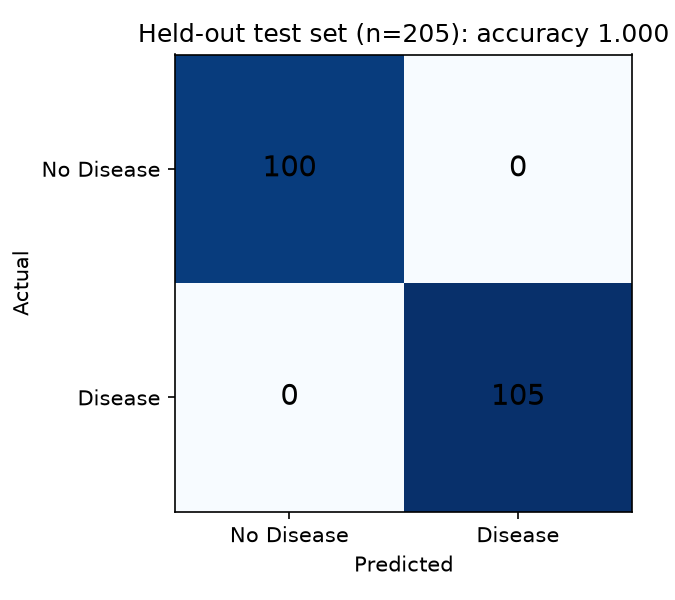

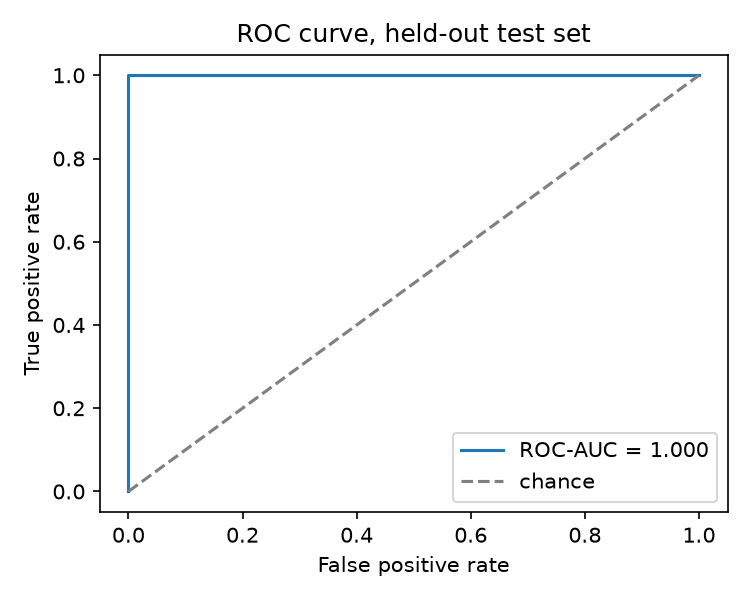

In [4]:
model = train_rf(X_train, y_train)
metrics = evaluate(model, X_test, y_test)

print(f"Held-out test accuracy: {metrics['accuracy']:.4f}")
print(f"Held-out ROC-AUC:       {metrics['roc_auc']:.4f}")
print(f"Confusion matrix (rows = actual, cols = predicted):")
print(metrics['confusion_matrix'])
display(Image(filename=str(ROOT / "figures" / "fig_confusion_matrix.png")))
display(Image(filename=str(ROOT / "figures" / "fig_roc_curve.png")))

## 4. Feature importance, three ways

- **Built-in impurity importance** comes free with the forest, but it is biased: it favors continuous features and splits credit between correlated ones. Shown for completeness, not trusted alone.
- **Permutation importance on the held-out test set** shuffles one feature at a time and measures how much accuracy drops. This is the honest ranking — it measures what the model actually relies on, on data it never saw during training. **This is the ranking the Tableau dashboard shows.**
- **SHAP values** answer the same "what matters" question but add *direction*: does a high value push risk up or down?

C:\Users\masum\Desktop\Vrunda\HEART PROJECT\heart-disease-tableau-dashboard\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Built-in impurity importance (biased, shown for reference) ===
 feature  importance
      cp    0.151167
 thalach    0.115185
      ca    0.111957
 oldpeak    0.103748
    thal    0.095052
     age    0.093055
    chol    0.078121
   exang    0.073002
trestbps    0.071053
   slope    0.046519
     sex    0.031476
 restecg    0.019704
     fbs    0.009961

=== Permutation importance on held-out test set (the honest ranking) ===
 feature  importance      std
      cp    0.080488 0.014836
      ca    0.071870 0.015319
    thal    0.050244 0.009605
 oldpeak    0.031870 0.009318
trestbps    0.015447 0.003581
     sex    0.014472 0.007067
   exang    0.013171 0.005366
     age    0.011545 0.005972
 thalach    0.008130 0.005393
    chol    0.005203 0.003970
 restecg    0.000000 0.000000
     fbs    0.000000 0.000000
   slope    0.000000 0.000000

=== SHAP: importance + direction ===
 feature  mean_abs_shap          direction
      cp       0.112612 higher raises risk
      ca       0.1006

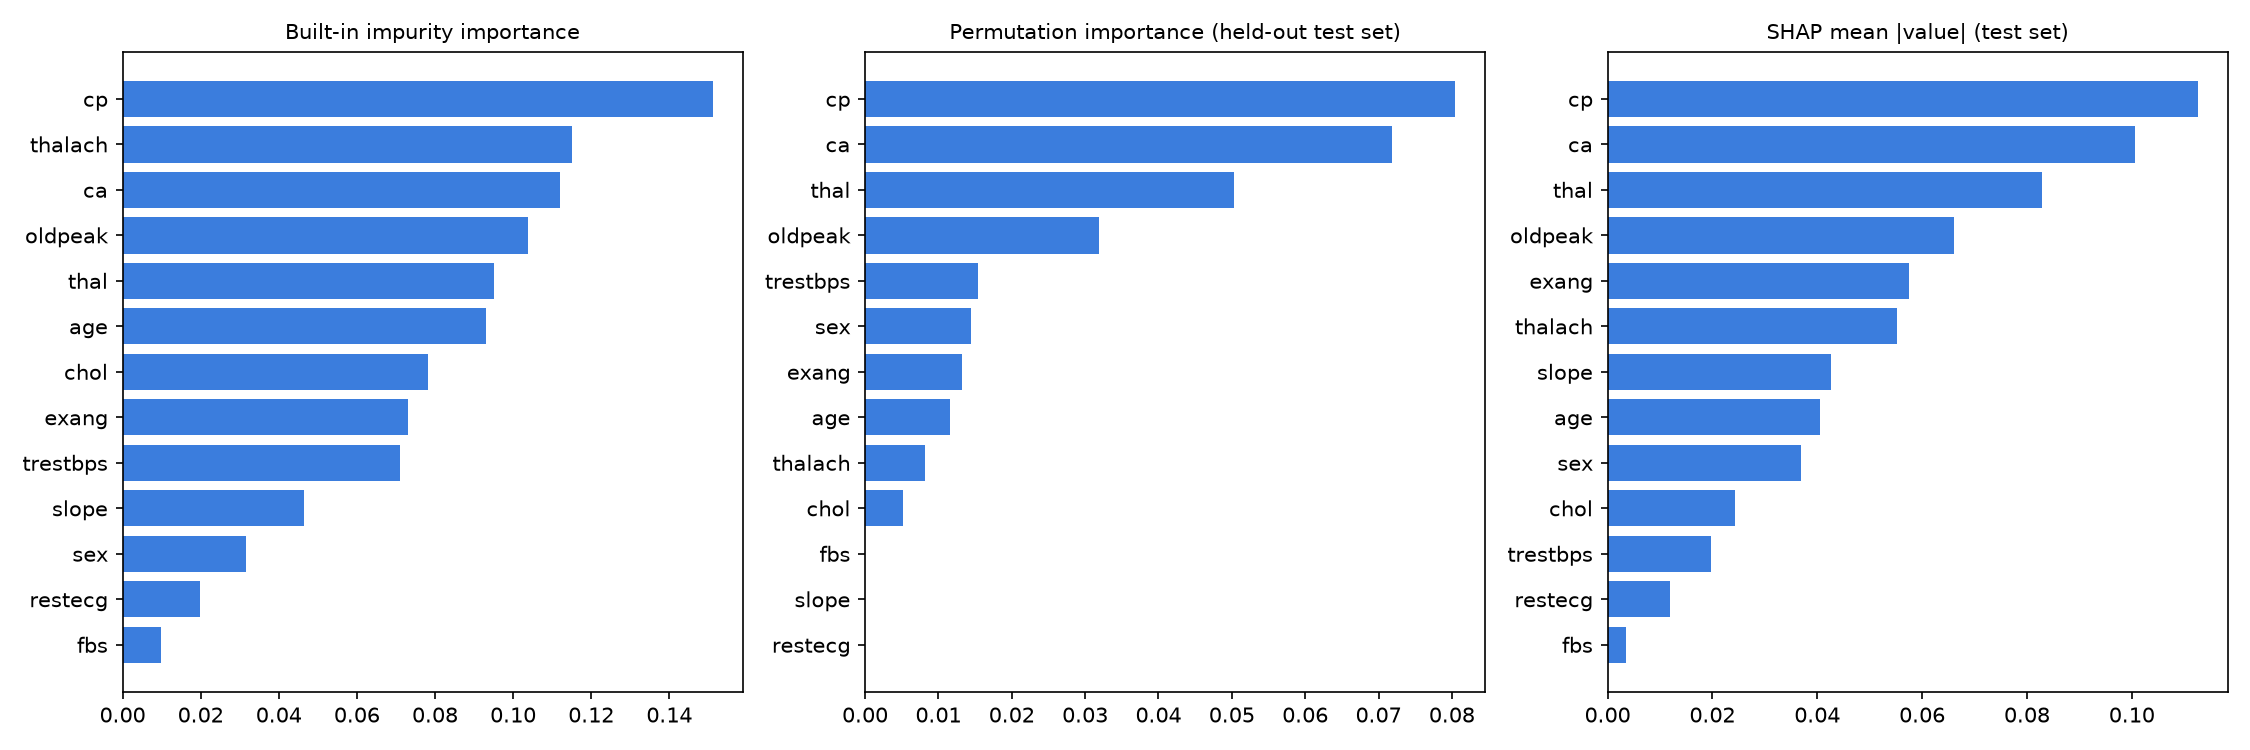

In [5]:
builtin = builtin_importance(model)
permutation = permutation_importance_table(model, X_test, y_test)
shap_table = shap_importance(model, X_test)

print("=== Built-in impurity importance (biased, shown for reference) ===")
print(builtin.to_string(index=False))
print("\n=== Permutation importance on held-out test set (the honest ranking) ===")
print(permutation.to_string(index=False))
print("\n=== SHAP: importance + direction ===")
print(shap_table.to_string(index=False))
display(Image(filename=str(ROOT / "figures" / "fig_importance_methods.png")))

## 5. Does importance shift by gender?

The headline question. A Random Forest is refit within each gender subgroup (train rows only), permutation importance is measured on that subgroup's held-out test rows, and the whole procedure is repeated over **500 bootstrap resamples** per subgroup to attach a 95% interval to every feature's importance.

The cell below loads the table produced by `python -m src.run_analysis` (the bootstrap takes a few minutes; rerunning it here would only slow the notebook down — the function is `src.gender.full_gender_analysis`).

**Language discipline.** If a feature ranks high for one gender and low for the other with *non-overlapping* intervals, the difference is supported. If intervals overlap, the honest verdict is "suggestive, not conclusive at this sample size".

          male_importance  female_importance  male_rank  female_rank
feature                                                             
ca                 0.1121             0.0113          1            4
cp                 0.0781             0.0177          2            3
oldpeak            0.0333             0.0000          3            9
thal               0.0263             0.0355          4            1
trestbps           0.0210             0.0000          5            9
age                0.0196             0.0054          6            5
thalach            0.0175             0.0000          7            9
chol               0.0117             0.0000          8            9
sex                0.0000             0.0000         11            9
exang              0.0000             0.0296         11            2
restecg            0.0000             0.0000         11            9
fbs                0.0000             0.0000         11            9
slope              0.0000         

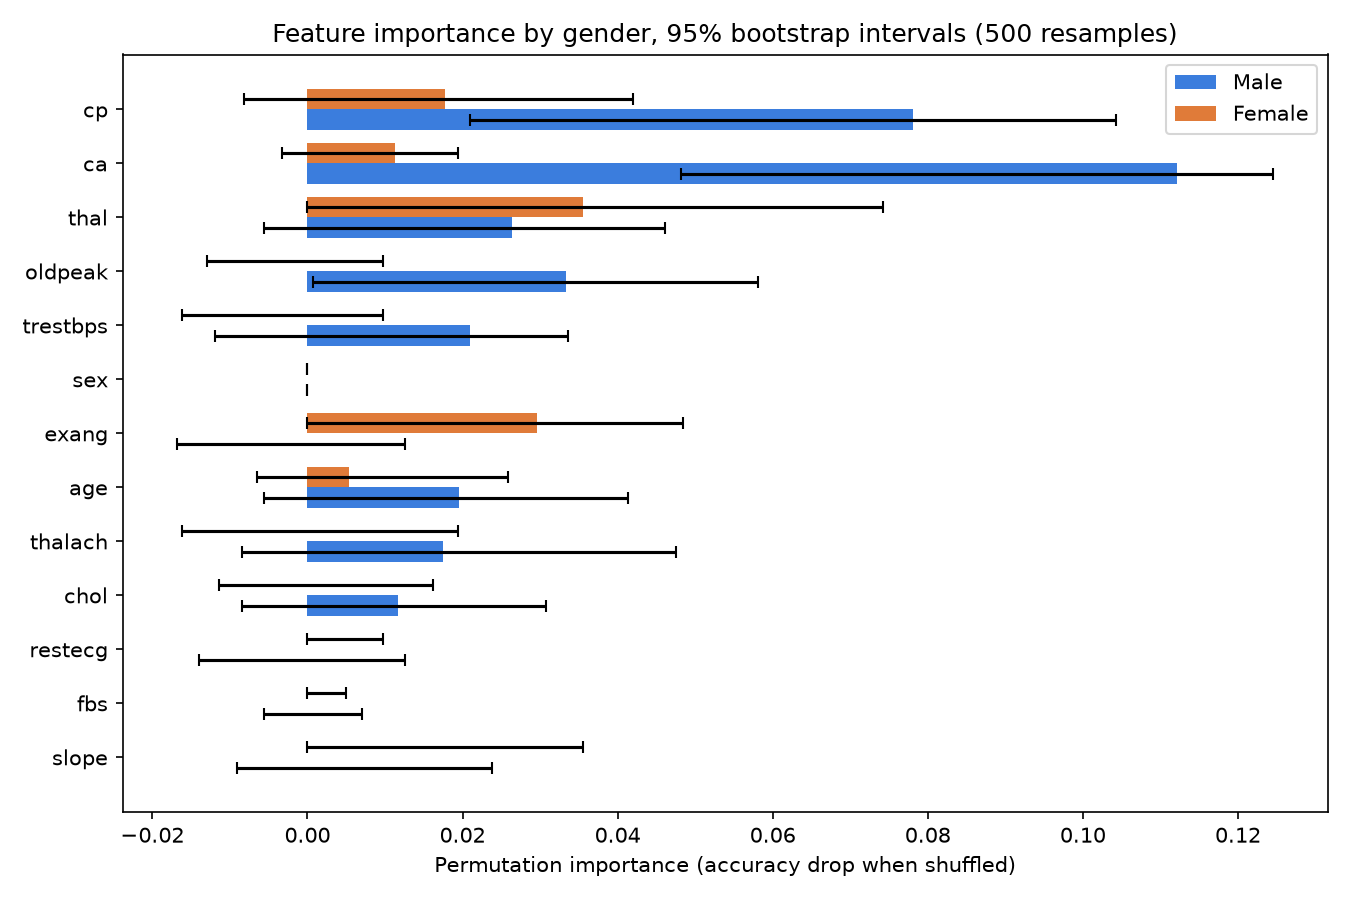

In [6]:
gender_ci = pd.read_csv(ROOT / "data" / "processed" / "gender_importance_ci.csv")

male = gender_ci[gender_ci["group"] == "Male"].set_index("feature")
female = gender_ci[gender_ci["group"] == "Female"].set_index("feature")
compare = male[["importance"]].rename(columns={"importance": "male_importance"}).join(
    female[["importance"]].rename(columns={"importance": "female_importance"})
)
compare["male_rank"] = compare["male_importance"].rank(ascending=False).astype(int)
compare["female_rank"] = compare["female_importance"].rank(ascending=False).astype(int)
print(compare.sort_values("male_importance", ascending=False).round(4).to_string())
print()
print(gender_ci.round(4).to_string(index=False))
display(Image(filename=str(ROOT / "figures" / "fig_gender_importance.png")))

**What the intervals say (seed 42, 500 resamples):**

- `ca` (vessels colored by fluoroscopy) is the **#1 feature for men** (importance ≈ 0.112, 95% CI [0.048, 0.124]) and drops to mid-table for women (≈ 0.011, CI [-0.003, 0.019]). The intervals do not overlap → **the gender difference for `ca` is supported**.
- `thal` and `exang` rank **higher for women** (#1 and #2) than for men (mid/low-table) → consistent with a shift, but the intervals overlap → **suggestive, not conclusive** at this sample size.
- `sex` alone scores near zero in the overall ranking — it is not a strong standalone predictor; it *modifies* which features matter.

## 6. What feeds the Tableau dashboard

`python -m src.run_analysis` writes two Tableau-ready exports to `data/processed/tableau/`:

- `tableau_feature_importance.csv` — the permutation importances above, long format (Overall / Male / Female, with 95% intervals for the gender groups). Powers the side-by-side gender view.
- `tableau_patients_labeled.csv` — all 1,025 patients with human-readable labels plus an age-group column. Powers the prevalence heatmap and grouped-bar views.

Dashboard filters (exact list): **gender, age group, chest-pain type**. See `tableau/build_spec.md` for the sheet-by-sheet build instructions.

## Summary

1. A Random Forest trained on 820 patients separates disease from no-disease on 205 held-out patients with accuracy 1.000 and ROC-AUC 1.000 — *predicts*, because it was measured on patients the model never saw.
2. The features that drive the predictions (permutation importance, held-out test set): `cp`, `ca`, `thal`, `oldpeak` — symptom type, vessel count, thalassemia test, ST depression. Metabolic indicators (`fbs`, `restecg`, `chol`) carry little weight.
3. The ranking **shifts by gender**: `ca` dominates for men with a non-overlapping interval; `thal` and `exang` lead for women, suggestively. No single symptom or test separates the classes on its own — the signal lives in combinations.

*Team: Vrunda Joshi (team lead), Meet Gandhi, Kashyap Patel, Masum Udecha — DS612 Interactive Data Visualization, Autumn 2026, Dhirubhai Ambani University. Presented in class with the course instructor as project jury.*